# Titanic Survival Analysis - Exploratory Data Analysis

This notebook performs the exploratory data analysis (EDA) for the Titanic dataset.

Goals:
- Understand data distributions  
- Analyze categorical and numerical variables  
- Explore relationships with the target variable (Survived)  
- Identify patterns and insights  
- Support future modeling  



# Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset


In [3]:
df = pd.read_csv('pd.read_csv("../data/processed/titanic_cleaned.csv")')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


##  Dataset Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


# Summary statistics

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Unique Values

In [6]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


###  Numerical Variables

We start by analyzing the distribution of numerical features to understand their spread, central tendency, and potential outliers.

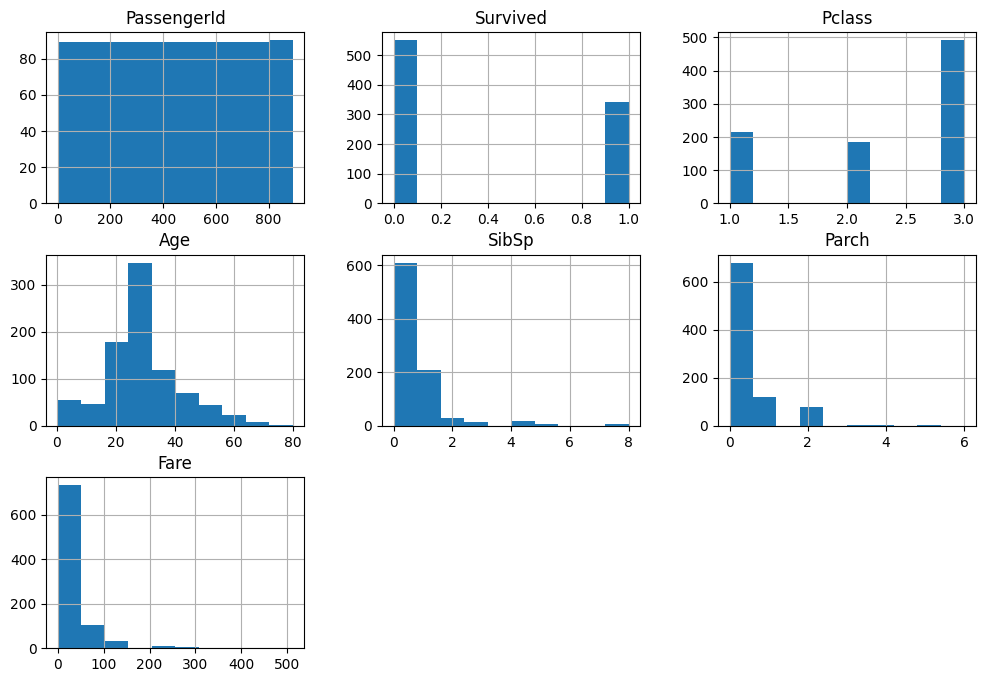

In [7]:
df.hist(figsize=(12,8))
plt.show()

###  Age Distribution

We analyze the distribution of passenger ages to understand the demographic profile of individuals aboard the Titanic.

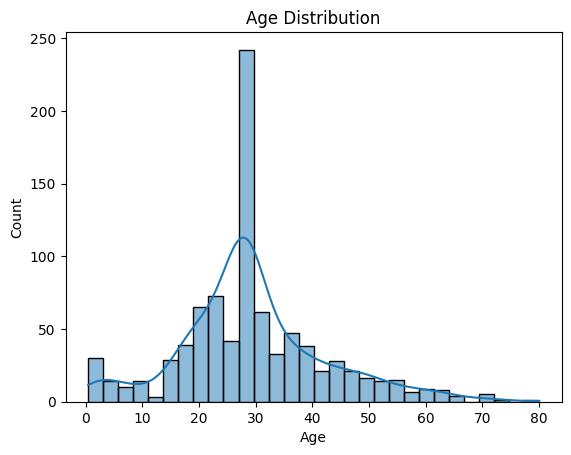

In [8]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

###  Fare Distribution

We examine the distribution of ticket fares to identify variability and detect possible skewness or extreme values.

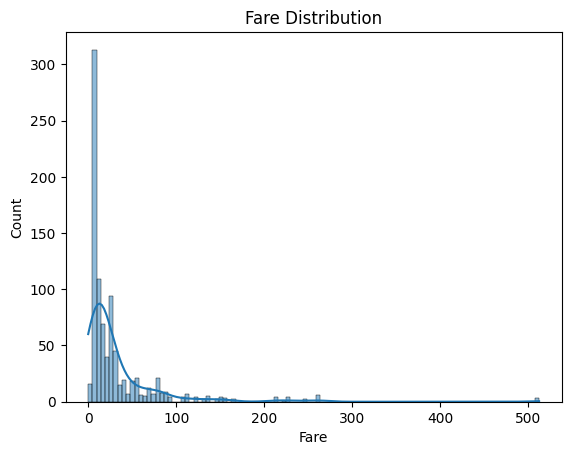

In [9]:
sns.histplot(df['Fare'], kde=True)
plt.title("Fare Distribution")
plt.show()

###  Survival Distribution

We analyze the balance between survivors and non-survivors in the dataset.

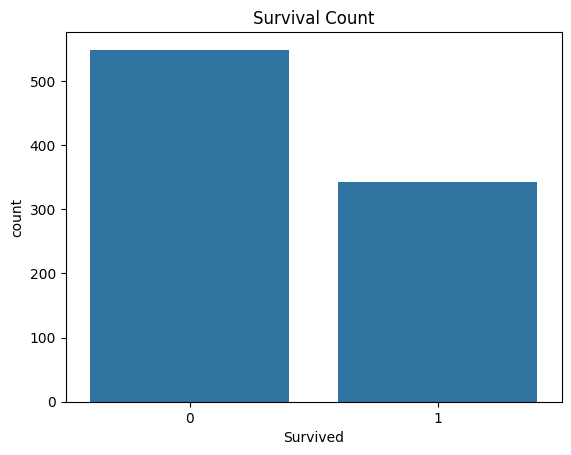

In [10]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

###  Gender Distribution

We examine the distribution of passengers by gender.

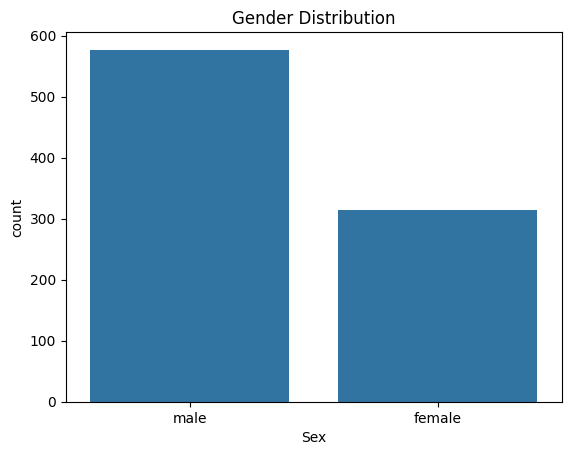

In [11]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

###  Passenger Class Distribution

We analyze how passengers are distributed across different ticket classes.

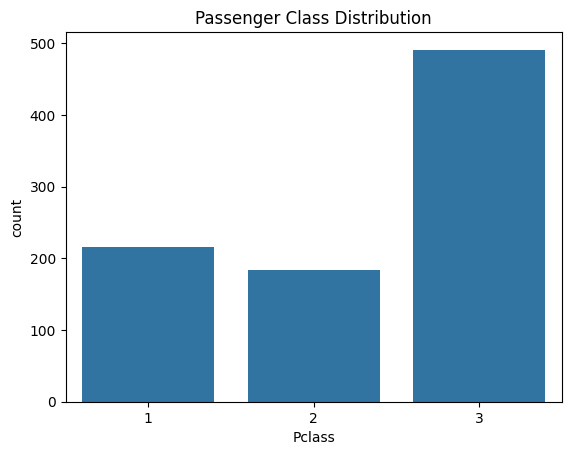

In [12]:
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

##  Bivariate Analysis

In this section, we analyze the relationship between different features and the target variable (Survived).

The goal is to identify which factors have the greatest influence on passenger survival and uncover meaningful patterns in the data.

###  Survival vs Gender

We analyze how survival rates differ between male and female passengers.

- Female passengers show a significantly higher survival rate compared to male passengers  
- This suggests that gender played a crucial role in survival outcomes  

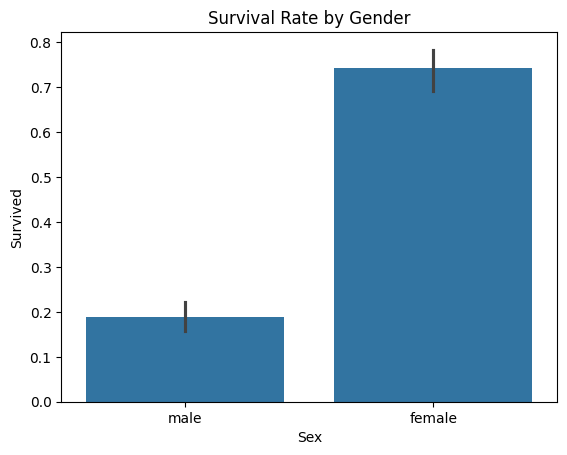

In [13]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

###  Survival vs Passenger Class

We examine how passenger class influenced survival rates.
- Passengers in higher classes (1st class) had higher survival rates  
- Lower-class passengers faced lower chances of survival  
- This may reflect differences in access to lifeboats and priority during evacuatio

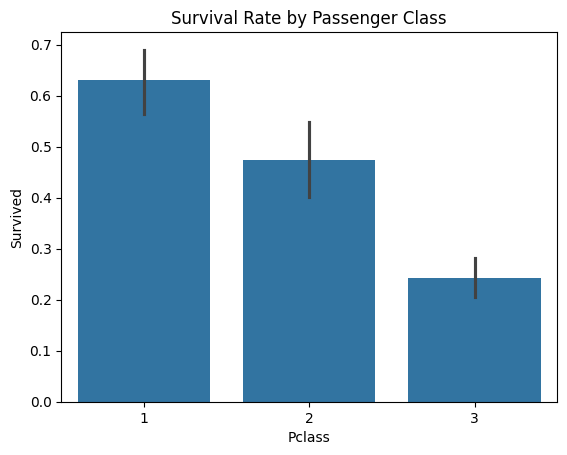

In [14]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

###  Survival vs Age

We analyze how age distribution differs between survivors and non-survivors.
- There may be differences in age distribution between survivors and non-survivors  
- Younger passengers might have had a survival advantage  

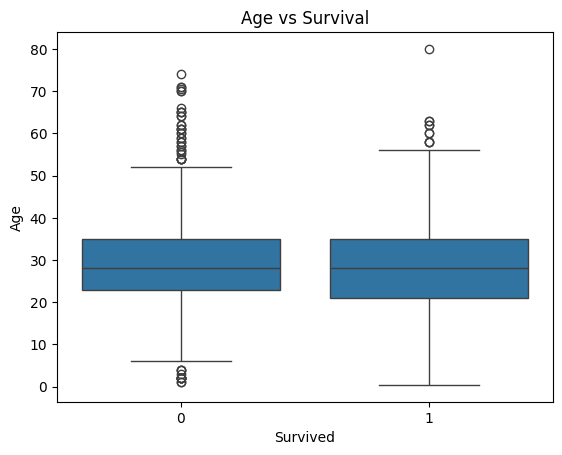

In [15]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

###  Survival vs Fare

We examine the relationship between ticket fare and survival.
- Higher fare passengers tend to have higher survival rates  
- This reinforces the relationship between socioeconomic status and survival  

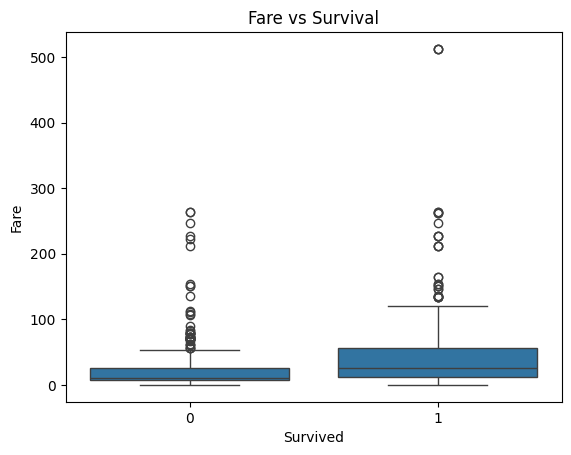

In [16]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()

###  Correlation Analysis

We analyze correlations between numerical variables to identify relationships and potential predictors of survival.
###  Note:

Categorical variables such as 'Sex' are not included in the correlation matrix at this stage.  
They will be encoded in the feature engineering step to allow further numerical analysis.

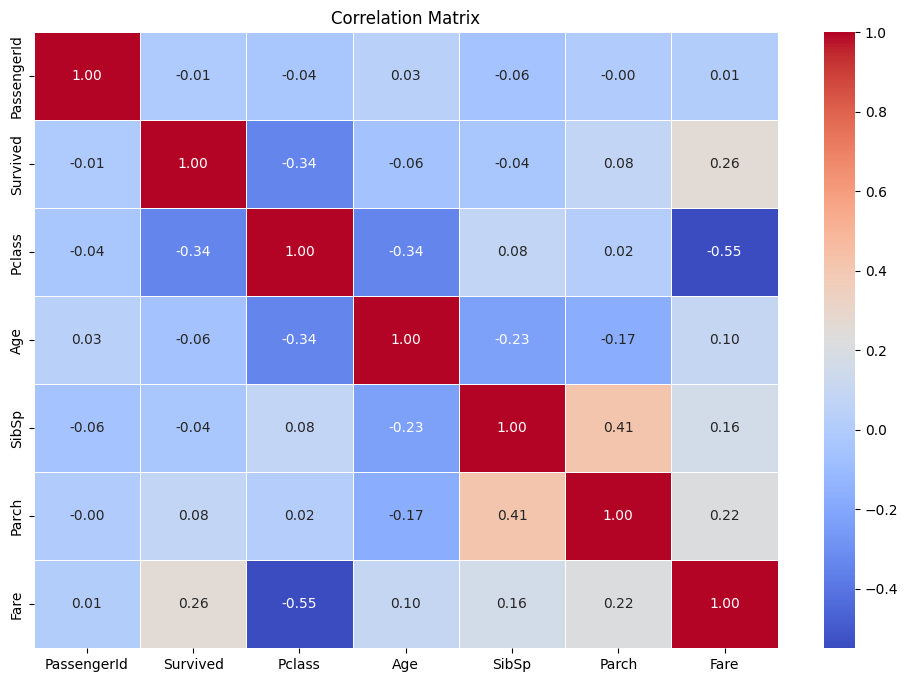

In [18]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12,8))
sns.heatmap(
    df_numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()